# Two-Tower Model (TTN)

Build a PyTorch two-tower model on the Home & Kitchen interactions and the
extracted item features. See `README.md` in this folder for the design.

BPR-style pairwise ranking loss: `-log σ(score(u, i) - score(u, j))`.

In [71]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

# Show every column/variable when displaying a dataframe
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", 50)
# Turn off scientific notation (e.g. 2.447268e+06 -> 2447268.00)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Load the user–item interactions

`data/Home_and_Kitchen_filtered.csv` is the interaction log: **one row per
review**, i.e. one row per (user, item, date) event. This is the table the
two-tower model is trained on — every other dataset in this notebook is joined
onto it.

**All 11 columns are loaded here** so the full contents are visible before
anything is thrown away. The next section decides what to keep.

`asin` and `reviewerID` are pinned to `str` so IDs with leading zeros
(e.g. `0560467893`) survive, and `low_memory=False` avoids the mixed-type
warning on `vote`.

In [72]:
from pathlib import Path

# data/ lives at the repo root, one level up from this ttn/ folder
DATA_DIR = Path("..") / "data"

df_reviews = pd.read_csv(
    DATA_DIR / "Home_and_Kitchen_filtered.csv",
    dtype={"asin": str, "reviewerID": str},
    low_memory=False,
)

print("df_reviews:", df_reviews.shape)
print("columns:", list(df_reviews.columns))
print(f"unique users: {df_reviews['reviewerID'].nunique():,} | "
      f"unique items: {df_reviews['asin'].nunique():,}")
df_reviews.head(5)

df_reviews: (6898955, 11)
columns: ['overall', 'verified', 'reviewTime', 'reviewerID', 'asin', 'reviewerName', 'summary', 'unixReviewTime', 'vote', 'style', 'image']
unique users: 777,242 | unique items: 189,172


,overall,verified,reviewTime,reviewerID,asin,reviewerName,summary,unixReviewTime,vote,style,image
0,5.00,True,"11 5, 2015",A8LUWTIPU9CZB,0560467893,Linda Fahner,Five Stars,1446681600,NaN,NaN,NaN
1,3.00,True,"05 7, 2015",A3B6GKQQ1JJ167,0560467893,Harry Slaughter,Meh,1430956800,2,NaN,NaN
2,5.00,True,"01 22, 2014",A3MCTN65BU7XRA,0681795107,luckyg,Recommend,1390348800,NaN,{'Color:': ' Brushed Stainless'},NaN
3,1.00,True,"10 30, 2013",A7JVZFSXVY9RL,0681795107,Nickleen,Not keeping coffee hot for long enough,1383091200,NaN,{'Color:': ' Brushed Stainless'},NaN
4,1.00,True,"09 20, 2013",A2RQ7VLAK1SHPU,0681795107,Lacemaker427,Leaks like a waterfall when at an angle!,1379635200,NaN,{'Color:': ' Red'},NaN


### Duplicate rows

The check below counts rows that are identical across **all** columns. Because
every column is now loaded, this is the true count of the same review being
recorded twice: **231,139 rows**.

**Note — the duplicates are an artefact of not holding every variable.** A
"duplicate" only ever means *identical across the variables we happen to have*,
and that is never the full record. `Home_and_Kitchen_filtered.csv` is itself a
projection of the original review dump — `reviewText`, the review body, isn't in
it at all — so two rows that look identical here may well have differed in a
column dropped upstream. The narrower the projection, the more rows collapse
together:

| Columns compared | Rows reported as duplicates |
| --- | --- |
| all 11 CSV columns | **231,139** |
| the 7 columns this notebook loaded before (`overall`, `verified`, `reviewTime`, `reviewerID`, `asin`, `unixReviewTime`, `vote`) | **248,121** |

The extra ~17k are the same user buying two *variants* of an item on the same
day — genuinely different interactions that become indistinguishable once
`style` and `summary` are gone.

So if you decide to drop the duplicates, do it here — before the removal step
below takes those columns away.

In [73]:
df_reviews.duplicated().sum()

np.int64(231139)

### Variables to remove from the interaction table

Two different reasons to drop a column, and it matters which one applies:

**(a) Post-interaction — would leak at serving time.** These only exist *after*
the purchase happened. At recommendation time we don't have them, so a model
trained on them learns from information it will never see in production.

| Column | Why remove |
| --- | --- |
| `overall` | The star rating, given after the purchase. Training here is **implicit** — the interaction itself is the positive signal, so the rating is neither needed as a label nor usable as an input. |
| `vote` | Helpfulness votes, accumulated by other users *after* the review is posted. Later still than the rating. Also almost entirely NaN. |
| `summary` | The review's text, written after the purchase. Post-interaction, and unstructured text these towers don't consume. |
| `image` | Customer photos uploaded with the review. Post-interaction, and nearly always empty. |

**(b) No signal / redundant.** Available at interaction time, but carrying
nothing the model can use.

| Column | Why remove |
| --- | --- |
| `reviewerName` | A display name, not an identifier — not unique, and changeable. `reviewerID` already identifies the user. |
| `style` | The variant chosen (`{'Color:': ' Brushed Stainless'}`). Known at purchase time, but it describes a *variant* while the model recommends at `asin` level, and it's a free-form dict string with very high cardinality. |

**Kept:**

| Column | Why keep |
| --- | --- |
| `reviewerID`, `asin` | The interaction itself — the user and item towers' keys. |
| `unixReviewTime` | The timeline. Needed for the temporal train/test split, and it's the key the user features are aligned on. |
| `reviewTime` | Human-readable duplicate of `unixReviewTime`. Kept only for spot-checks; safe to drop for a leaner frame. |
| `verified` | A property of the *transaction*, not of the review content, so it's known at interaction time. Useful later as an interaction-quality filter — not as a tower input. |

⚠️ **One caveat about dropping `style` and `summary`:** they're what distinguishes
a genuine same-day purchase of two *different variants* of an item from the same
review being recorded twice — see the duplicate check above. If you de-duplicate
the log, do it **before** this cell; deduping afterwards collapses ~17k real
interactions.

In [74]:
# (a) post-interaction — known only after the purchase, would leak at serving time
POST_INTERACTION = ["overall", "vote", "summary", "image"]

# (b) no signal / redundant
NO_SIGNAL = ["reviewerName", "style"]

DROP_COLS = POST_INTERACTION + NO_SIGNAL

df_reviews = df_reviews.drop(columns=[c for c in DROP_COLS if c in df_reviews.columns])

print(f"dropped {len(DROP_COLS)}: {DROP_COLS}")
print(f"kept    {df_reviews.shape[1]}: {list(df_reviews.columns)}")
print("\ndf_reviews:", df_reviews.shape)
df_reviews.head(5)

dropped 6: ['overall', 'vote', 'summary', 'image', 'reviewerName', 'style']
kept    5: ['verified', 'reviewTime', 'reviewerID', 'asin', 'unixReviewTime']

df_reviews: (6898955, 5)


,verified,reviewTime,reviewerID,asin,unixReviewTime
0,True,"11 5, 2015",A8LUWTIPU9CZB,0560467893,1446681600
1,True,"05 7, 2015",A3B6GKQQ1JJ167,0560467893,1430956800
2,True,"01 22, 2014",A3MCTN65BU7XRA,0681795107,1390348800
3,True,"10 30, 2013",A7JVZFSXVY9RL,0681795107,1383091200
4,True,"09 20, 2013",A2RQ7VLAK1SHPU,0681795107,1379635200


## 2. Item features

`data/df_features.pkl` — one row per `asin` (~1.13M items) with the attributes
extracted by `feature_extraction_workflow/extract_features.py`: `cat_*`,
`brand`, the per-field columns (`Product_Type`, `Material`, `Color`, …), their
parsed `_numeric` / `_unit` / `_cleaned` measures, and `title_cleaned`.

It is loaded and **analysed on its own first**. The join onto the interactions
happens in §4, once the checks below have settled which columns are worth
carrying.

In [75]:
from pathlib import Path

# data/ lives at the repo root, one level up from this ttn/ folder
DATA_DIR = Path("..") / "data"

# --- Item features (one row per asin) ---
df_features = pd.read_pickle(DATA_DIR / "df_features.pkl")
print("df_features:", df_features.shape)
df_features.head(3)

df_features: (1134566, 82)


,category,tech1,description,title,tech2,brand,feature,rank,main_cat,price,asin,date,imageURL,imageURLHighRes,cat_1,cat_2,cat_3,cat_4,cat_5,cat_6,title_cleaned,extracted_features_title,description_cleaned,extracted_features_description,feature_cleaned,extracted_features_feature,extracted_features,Bar_Pressure,Brand,Capacity_Cups,Capacity_Volume,Color,Density_Weight,Dimensions,Features,Filter_Rating,Material,Part_Number,Piece_Count,Pocket_Depth,Power_Rating,Product_Type,Scent,Shape,Shape_Style,Size,Stage_Count,Sub_Type,Theme,Thread_Count,Voltage,Weight,capacity_volume_numeric,capacity_volume_unit,piece_count_numeric,piece_count_unit,thread_count_numeric,thread_count_unit,weight_numeric,weight_unit,bar_pressure_numeric,capacity_cups_numeric,density_weight_lb,pocket_depth_in,power_rating_w,stage_count_numeric,voltage_numeric,dimension_1,dimension_2,dimension_3,dimension_unit,bar_pressure_numeric_cleaned,capacity_cups_numeric_cleaned,density_weight_lb_cleaned,pocket_depth_in_cleaned,power_rating_w_cleaned,stage_count_numeric_cleaned,voltage_numeric_cleaned,capacity_volume_numeric_cleaned,weight_numeric_cleaned,piece_count_numeric_cleaned,thread_count_numeric_cleaned
0,"['Home & Kitchen', 'Kitchen & Dining', 'Dining...",NaN,['It was a time honored tradition among the ea...,You Are Special Today Red Plate [With Red Pen],NaN,Waechtersbach USA,[],"['>#39,665 in Kitchen & Dining (See Top 100 in...",Amazon Home,$37.00,0001487795,"October 8, 2006",[],[],Home & Kitchen,Kitchen & Dining,Dining & Entertaining,Dinnerware,Plates,Dinner Plates,special today red plate red pen,{'Color': 'red'},time honored tradition among early american fa...,{'Color': 'red'},,{},{'Color': 'red'},None,None,None,None,red,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"['Home & Kitchen', 'Home Dcor', 'Candles & Hol...",NaN,['VICKS INHALER relieves stuffy noses helps si...,Vicks Inhaler Relief for Cold Sinus Nasal Cong...,NaN,Vicks,[],"['>#1,763,185 in Home & Kitchen (See Top 100 i...",Amazon Home,$4.05,0002020300,NaN,[],[],Home & Kitchen,Home Dcor,Candles & Holders,Candles,None,None,vicks inhaler relief cold sinus nasal congesti...,{},vicks inhaler relief stuffy nose help sinus co...,{},,{},{},None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"['Home & Kitchen', 'Kitchen & Dining', 'Dining...",NaN,"['16 oz squeeze bottle, 1 lb.']",Artistic Churchware Communion Cup Filler: RW525,NaN,Artistic Churchware,"['Religious Supply Center', 'RW-525', 'Communi...","['>#2,127,003 in Home & Kitchen (See Top 100 i...",Amazon Home,$12.48,0006564224,NaN,[],[],Home & Kitchen,Kitchen & Dining,Dining & Entertaining,Glassware & Drinkware,Wine & Champagne Glasses,None,artistic churchware communion cup filler rw525,{'Product_Type': 'cup'},16 oz squeeze bottle 1 lb,{'Capacity_Volume': '16 oz'},religious supply center rw-525 communion cup f...,{'Product_Type': 'cup'},"{'Product_Type': 'cup', 'Capacity_Volume': '16...",None,None,None,16 oz,None,None,None,None,None,None,None,None,None,None,cup,None,None,None,None,None,None,None,None,None,None,16.00,oz,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.00,NaN,NaN,NaN


## 3. Examine the item features — before joining

These columns are not ready to feed a tower as they stand, and this section is
the checklist that decides which of them survive.

**Why the analysis runs here, on `df_features`, and not after the join:** this
table is one row per `asin`. The merged frame repeats an item once per review,
so every distribution measured there is **popularity-weighted** — a `Color`
count on the merged frame describes reviews, not the catalog, and a heavily
reviewed item drags the numbers toward its own attributes. The keep/drop
decision is about item variables, so it belongs on the item table. It is also
1.13M rows instead of 6.9M.

(Coverage *over interactions* is a separate and also useful question — a field
present on few items can still cover many reviews. That one is worth checking
after the join in §4.)

What needs a look first:

- **Redundancy.** Several fields appear twice — the raw extracted string
  (`Weight`, `Piece_Count`, `Thread_Count`) and the parsed `_numeric` + `_unit`
  (+ range-cleaned `_cleaned`) version. Feeding both feeds the same information
  twice.
- **Mixed units.** Raw numbers aren't comparable until units are reconciled:
  `weight_numeric` mixes `lb` and `g`, `dimension_*` mixes `in` and `cm`. A
  model reading the number without the unit treats `1 lb` and `1 g` alike.
- **Cardinality.** `brand` has 27,909 distinct values and `Product_Type` 1,129,
  while `Color` has 67 and `Size` 20 — which drives embedding vs. one-hot vs.
  drop.
- **Coverage.** Some fields are populated on a small slice of items
  (`bar_pressure_numeric_cleaned`: ~9k). A near-empty column adds parameters
  and noise, not signal.
- **Text that is really numeric.** `Filter_Rating` holds `'5 micron'`,
  `'40 gallon'` — a number and a unit in one unparsed string.

Nothing is dropped until the checks below have all been run.

**First**, I need to standardize the numerical values of features and make them in the same units (e.g., inch -> cm). Once I do that, I may need to exclude some of the feature variables.

**Variables to Exclude** <br>
**Bar_Pressure:** a bar_pressure_numeric_cleaned variable is created that includes the necessary information <br>
**extracted_features:** every features is stored as a separate variables <br>
**Capacity_Cups:** capacity_cups_numeric_cleaned is the cleaned version <br>
**Density_weight:** density_weight_lb_cleaned is the cleaned version <br>
**Pocket_Depth:** pocket_depth_in_cleaned is the cleaned version <br>
**Power_Rating:** power_rating_w_cleaned is the cleaned version <br>
**Stage_Count:** stage_count_numeric_cleaned is the cleaned version <br>
**Voltage:** voltage_numeric_cleaned is the cleaned version <br>
**Thread_Count:** thread_count_numeric_cleaned and thread_count_unit are the cleaned versions <br>
**Weight:** weight_numeric_cleaned and weight_unit are the cleaned versions <br>
**Capacity:** removed from `master_metadata.json` entirely — its patterns duplicated Capacity_Cups (cups) and Capacity_Volume (oz/litres) in the same Coffee, Tea & Espresso schema, so `capacity_numeric` / `capacity_unit` are no longer produced <br>
**Capacity_Volume:** capacity_volume_numeric and capacity_volume_unit are the cleaned versions <br>
**Piece_Count:** piece_count_numeric and piece_count_unit are the cleaned versions

## **Variables to Check** <br>
**Categorical Variables** <br>
brand <br>
Brand <br>
Color <br>
Features <br>
Filter_Rating <br>
Material <br>
Part_Number <br>
Product_Type <br>
Scent <br>
Shape <br>
Shape_Style <br>
Size <br>
Sub_Type <br>
Theme <br>
<br>
<br>
**Variables consisting of two parts: unit and value**
<br>
1 capacity_volume_numeric <br>
2 capacity_volume_unit <br>
<br>
1 piece_count_numeric <br>
2 piece_count_unit <br>
<br>
1 thread_count_numeric <br>
2 thread_count_unit <br>
<br>
1 weight_numeric <br>
2 weight_unit <br>
<br>
<br>
**Variables with Range Filters** <br>
bar_pressure_numeric_cleaned <br>
capacity_cups_numeric_cleaned <br>
density_weight_lb_cleaned <br>
pocket_depth_in_cleaned <br>
power_rating_w_cleaned <br>
stage_count_numeric_cleaned <br>
voltage_numeric_cleaned <br>
<br>
**Dimension Variables** <br>
dimension_1 <br>
dimension_2 <br>
dimension_3 <br>
dimension_unit <br>
<br>
**Product Categories** <br>
cat_2 <br>
cat_3 <br>
cat_4 <br>


### 3.1 Product categories — `cat_2` / `cat_3` / `cat_4`

The three category levels, checked first because they are the strongest
candidates for the item tower. `cat_2` and `cat_3` are usable as they stand —
`filter_by_cat_3` already validated level 3 against `master_metadata.json`.
`cat_4` is not, and the cells below clean it.

In [76]:
# Check categories: cat_2, cat_3, and cat_4
print(f'Number of unique cat_2 values: \n {df_features['cat_2'].nunique()}')
print(f'Unique cat_2 values: \n {df_features['cat_2'].unique()}')
print(f'Number of unique cat_3 values: \n {df_features['cat_3'].nunique()}')
print(f'Unique cat_3 values: \n {df_features['cat_3'].unique()}')
print(f'Number of unique cat_4 values: \n {df_features['cat_4'].nunique()}')
print(f'Unique cat_4 values: \n {df_features['cat_4'].unique()}')

Number of unique cat_2 values: 
 7
Unique cat_2 values: 
 ['Kitchen & Dining' 'Home Dcor' 'Bath' 'Wall Art' 'Bedding' 'Furniture'
 "Kids' Home Store"]
Number of unique cat_3 values: 
 69
Unique cat_3 values: 
 ['Dining & Entertaining' 'Candles & Holders' 'Bathroom Accessories'
 'Home Fragrance' 'Posters & Prints' "Kids' Bedding"
 'Storage & Organization' 'Home Dcor Accents' 'Blankets & Throws'
 'Kitchen Utensils & Gadgets' 'Travel & To-Go Drinkware' 'Clocks'
 'Picture Frames' 'Bakeware' 'Small Appliances' 'Quilts & Sets'
 'Bed Pillows & Positioners' 'Home Brewing & Wine Making'
 'Photo Albums & Accessories' 'Tapestries' "Kids' Furniture"
 'Comforters & Sets' 'Game & Recreation Room Furniture' "Kids' Room Dcor"
 'Duvets, Covers & Sets' 'Kitchen & Table Linens'
 'Area Rugs, Runners & Pads' 'Small Appliance Parts & Accessories'
 'Cutlery & Knife Accessories' 'Artificial Plants & Flowers'
 'Gift Baskets' 'Window Treatment Hardware' 'Cookware'
 'Home Office Furniture' 'Coffee, Tea & Espress

#### Cleaning `cat_4` with `category_taxonomy.json`

The check above shows ~920 distinct `cat_4` values, and most of them are not
categories at all — they are **product bullets that leaked into the category
path**: `10" high`, `Imported`, `Material:Paper+Plastic`,
`</span></span></span>`. `ensure_cat_columns` parses the source `category`
list positionally, so when an item's list has bullets appended after the real
taxonomy path, they land in `cat_4` and below. Note that `cat_3` is clean:
`filter_by_cat_3` keeps only rows whose `cat_3` matches a key in
`master_metadata.json`. Nothing validates level 4 — hence the mess.

**How the valid list was decided.** For every `cat_2 / cat_3 / cat_4` path we
counted the **number of unique items (`asin`) carrying it**. That count is the
signal: a real category is shared by many products, while a bullet belongs to
exactly one listing and shows up with a count of 1. Values below ~20 items were
treated as invalid, and the ones above the threshold were eyeballed as well —
which caught three that frequency alone would have kept (`Canvas` at 26,
`High quality poster paper material` at 24, `</span></span></span>` at 46,
all under Posters & Prints).

Those decisions are stored in **`data/category_taxonomy.json`** as the surviving
hierarchy: `cat_2 → cat_3 → [valid cat_4 values]`.

**The rule applied below:**

| Case | Result |
| --- | --- |
| `cat_4` is in its `cat_3`'s list | kept unchanged |
| `cat_4` is absent from the source path (`NaN`) | `Missing` |
| anything else (bullet text, or too few items) | `<cat_3>_Other` |

Backing off to the **parent** rather than one global `Other` matters: a shared
bucket would force the embedding for `Other` to average a poster bullet and a
kitchen bullet into one meaningless vector. `Bakeware_Other` instead sits
naturally near `Bakeware`, and says something true — "a bakeware item with no
usable subcategory".

Result: **921 → 451 distinct values**, and it costs almost nothing —
about **0.1% of items** end up in an `_Other` bucket.

In [77]:
import json

TAXONOMY_PATH = DATA_DIR / "category_taxonomy.json"
with open(TAXONOMY_PATH) as f:
    taxonomy = json.load(f)

# cat_3 -> the set of cat_4 values that survived the review
valid_cat_4 = {c3: set(vals) for c2 in taxonomy for c3, vals in taxonomy[c2].items()}
print(f"taxonomy: {len(taxonomy)} cat_2 | {len(valid_cat_4)} cat_3 | "
      f"{sum(len(v) for v in valid_cat_4.values())} valid cat_4 slots")

MISSING = "Missing"
OTHER_SUFFIX = "_Other"

cat_3 = df_features["cat_3"].astype(str)
cat_4 = df_features["cat_4"].fillna(MISSING).astype(str)

# A value is kept only if it is valid *under its own parent* — the same label
# can be real in one branch and junk in another.
valid_pairs = {(c3, v) for c3, vals in valid_cat_4.items() for v in vals}
keep = pd.Series(list(zip(cat_3, cat_4)), index=df_features.index).isin(valid_pairs)

df_features["cat_4_clean"] = np.where(keep, cat_4, cat_3 + OTHER_SUFFIX)

n_before = df_features["cat_4"].nunique(dropna=False)
n_after = df_features["cat_4_clean"].nunique()
n_folded = int((~keep).sum())
print(f"\ndistinct cat_4 : {n_before:,} -> {n_after:,}")
print(f"items folded into '<cat_3>{OTHER_SUFFIX}': {n_folded:,} "
      f"({n_folded / len(df_features) * 100:.2f}% of the catalog)")
df_features[["asin", "cat_2", "cat_3", "cat_4", "cat_4_clean"]].head(5)

taxonomy: 7 cat_2 | 69 cat_3 | 521 valid cat_4 slots

distinct cat_4 : 921 -> 451
items folded into '<cat_3>_Other': 1,099 (0.10% of the catalog)


,asin,cat_2,cat_3,cat_4,cat_4_clean
0,0001487795,Kitchen & Dining,Dining & Entertaining,Dinnerware,Dinnerware
1,0002020300,Home Dcor,Candles & Holders,Candles,Candles
2,0006564224,Kitchen & Dining,Dining & Entertaining,Glassware & Drinkware,Glassware & Drinkware
3,0009046461,Bath,Bathroom Accessories,None,Missing
4,0234937912,Home Dcor,Home Fragrance,Incense & Incense Holders,Incense & Incense Holders


In [78]:
# Check categories: cat_2, cat_3, and cat_4
print(f'Number of unique cat_2 values: \n {df_features['cat_2'].nunique()}')
print(f'Unique cat_2 values: \n {df_features['cat_2'].unique()}')
print(f'Number of unique cat_3 values: \n {df_features['cat_3'].nunique()}')
print(f'Unique cat_3 values: \n {df_features['cat_3'].unique()}')
print(f'Number of unique cat_4 values: \n {df_features['cat_4_clean'].nunique()}')
print(f'Unique cat_4 values: \n {df_features['cat_4_clean'].unique()}')

Number of unique cat_2 values: 
 7
Unique cat_2 values: 
 ['Kitchen & Dining' 'Home Dcor' 'Bath' 'Wall Art' 'Bedding' 'Furniture'
 "Kids' Home Store"]
Number of unique cat_3 values: 
 69
Unique cat_3 values: 
 ['Dining & Entertaining' 'Candles & Holders' 'Bathroom Accessories'
 'Home Fragrance' 'Posters & Prints' "Kids' Bedding"
 'Storage & Organization' 'Home Dcor Accents' 'Blankets & Throws'
 'Kitchen Utensils & Gadgets' 'Travel & To-Go Drinkware' 'Clocks'
 'Picture Frames' 'Bakeware' 'Small Appliances' 'Quilts & Sets'
 'Bed Pillows & Positioners' 'Home Brewing & Wine Making'
 'Photo Albums & Accessories' 'Tapestries' "Kids' Furniture"
 'Comforters & Sets' 'Game & Recreation Room Furniture' "Kids' Room Dcor"
 'Duvets, Covers & Sets' 'Kitchen & Table Linens'
 'Area Rugs, Runners & Pads' 'Small Appliance Parts & Accessories'
 'Cutlery & Knife Accessories' 'Artificial Plants & Flowers'
 'Gift Baskets' 'Window Treatment Hardware' 'Cookware'
 'Home Office Furniture' 'Coffee, Tea & Espress

**`cat_4` is clean: 921 → 451 distinct values.**

| Column | Distinct values | State |
| --- | --- | --- |
| `cat_2` | 7 | unchanged — usable as-is |
| `cat_3` | 69 | unchanged — already validated upstream |
| `cat_4` (raw) | 921 | left on the frame untouched, mostly bullet text |
| **`cat_4_clean`** | **451** | what the model sees from here on |

⚠️ The printout above reads **`cat_4_clean`** — only the label in the `print`
still says `cat_4`. The `451` is therefore the cleaned column; raw `cat_4` is
still 921 and is kept only for reference.

Where the 451 come from: `category_taxonomy.json` holds 521 surviving
`(cat_3, cat_4)` pairs — the same label can be valid under one parent and junk
under another, so a pair is the unit of validity. Collapsed to distinct labels
and combined with the two fallback buckets — `Missing` where the source path had
no level 4, and `<cat_3>_Other` for everything rejected — that leaves 451
values. The rejection is cheap: only **1,099 items (0.10% of the catalog)** land
in an `_Other` bucket, so nearly every item keeps a real subcategory.

`cat_4_clean` is the category column to use from here — §4 carries it into the
merged frame in place of `cat_4`.

In [101]:
df_features['piece_count_numeric_cleaned']

0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
          ... 
1300535    NaN
1300536    NaN
1300537   2.00
1300538    NaN
1300539    NaN
Name: piece_count_numeric_cleaned, Length: 1134566, dtype: float64

### 3.2 Variables with range filters

The single-scale numeric variables — `bar_pressure_numeric`,
`capacity_cups_numeric`, `density_weight_lb`, `pocket_depth_in`,
`power_rating_w`, `stage_count_numeric`, `voltage_numeric`. Each is always in
one unit, so a `[low, high]` here is a statement about the quantity itself
(mains voltage really is 110–240 V), not just a junk guard.

`range_report()` shows the **`_cleaned`** columns — the distribution that
survives the range currently in force — with the bounds drawn as dashed rules
and `removed_%` saying what each one cost. The quantile table runs out to
`p95, p96, p97, p98, p99`, since that is where a bound gets decided.

To judge whether a bound sits in the right place, compare it against the
unfiltered shape: `range_report(suffix="")` plots the same variables from the
raw columns. A smooth taper running through the dashed line there means the
bound is cutting live values; a gap with isolated bars beyond it means the tail
is parse junk and the cut is free.

The four two-part variables are deliberately excluded — they still mix units
within one column, so their bounds mean something different. They have their own
section below.

In [84]:
for i in ('bar_pressure_numeric', 'bar_pressure_numeric_cleaned',
          'capacity_cups_numeric', 'capacity_cups_numeric_cleaned',
          'density_weight_lb', 'density_weight_lb_cleaned',
          'pocket_depth_in', 'pocket_depth_in_cleaned',
          'power_rating_w', 'power_rating_w_cleaned',
          'stage_count_numeric', 'stage_count_numeric_cleaned',
          'voltage_numeric', 'voltage_numeric_cleaned'):

    print(f'Summary of {i}: \n {df_features[i].describe()}')

Summary of bar_pressure_numeric: 
 count     460.00
mean       20.79
std        95.96
min         0.00
25%        15.00
50%        15.00
75%        19.00
max     2,012.00
Name: bar_pressure_numeric, dtype: float64
Summary of bar_pressure_numeric_cleaned: 
 count   455.00
mean     15.38
std       4.12
min       1.00
25%      15.00
50%      15.00
75%      19.00
max      20.00
Name: bar_pressure_numeric_cleaned, dtype: float64
Summary of capacity_cups_numeric: 
 count    2,701.00
mean        62.77
std      1,880.72
min          0.00
25%          4.00
50%          8.00
75%         12.00
max     69,212.00
Name: capacity_cups_numeric, dtype: float64
Summary of capacity_cups_numeric_cleaned: 
 count   2,663.00
mean        7.44
std         4.17
min         1.00
25%         4.00
50%         8.00
75%        12.00
max        30.00
Name: capacity_cups_numeric_cleaned, dtype: float64
Summary of density_weight_lb: 
 count   341.00
mean     14.70
std      56.23
min       1.00
25%       3.00
50%      

### 3.3 Variables consisting of two parts (value + unit)

`Capacity_Volume`, `Piece_Count`, `Thread_Count` and `Weight` each produce a
`<field>_numeric` **and** a `<field>_unit` column. The number alone is
meaningless — `1.5` is litres or ounces depending on what the unit column says
on that row — so these can't be read like the single-scale variables in §3.2.

Two views below, because they answer different questions:

- `distribution_by_unit(field)` — one panel per unit, each on its own scale.
  Use it to see the shape of a single unit's distribution and where its tail
  stops being real.
- `plot_by_unit(field)` — one histogram, stacked and coloured by unit. Use it to
  compare units against each other: whether one sits systematically higher than
  the rest, and whether it is a genuine measurement or junk to drop.

Both print a quantile table out to `p95, p96, p97, p98, p99`, which is where a
bound gets decided.

The bounds now in force on these four are plausibility guards rather than
statements about a quantity — they cannot be tighter until each column is
converted to a single unit.

In [86]:
# Summary of the two-part variables, after range cleaning
TWO_PART_CLEANED = [
    "capacity_volume_numeric_cleaned",
    "piece_count_numeric_cleaned",
    "thread_count_numeric_cleaned",
    "weight_numeric_cleaned",
]

present = [c for c in TWO_PART_CLEANED if c in df_features.columns]
missing = [c for c in TWO_PART_CLEANED if c not in df_features.columns]

if missing:
    # These bounds were added to VALID_RANGES after this pickle was written, so
    # the columns appear only once extraction is re-run.
    print("not in this pickle yet — produced by the next extraction run:")
    for c in missing:
        print(f"    {c}")
    print()

display(df_features[present].describe().T)

# non-null counts against the raw column, i.e. what the range removed
for c in present:
    raw = c[: -len("_cleaned")]
    if raw in df_features.columns:
        n_raw, n_clean = df_features[raw].notna().sum(), df_features[c].notna().sum()
        print(f"{raw:26s} {n_raw:>8,} -> {n_clean:>8,}   "
              f"({n_raw - n_clean:,} removed by the range)")

,count,mean,std,min,25%,50%,75%,max
capacity_volume_numeric_cleaned,"113,961.00",25.95,75.55,0.01,6.40,12.00,16.00,976.00
piece_count_numeric_cleaned,"155,757.00",12.20,34.21,1.00,2.00,4.00,8.00,500.00
thread_count_numeric_cleaned,"19,310.00",613.77,420.19,3.00,300.00,450.00,800.00,"2,000.00"
weight_numeric_cleaned,252.00,16.92,60.24,0.45,1.00,2.00,5.00,500.00


capacity_volume_numeric     114,224 ->  113,961   (263 removed by the range)
piece_count_numeric         157,366 ->  155,757   (1,609 removed by the range)
thread_count_numeric         19,346 ->   19,310   (36 removed by the range)
weight_numeric                  252 ->      252   (0 removed by the range)


### 3.4 Categorical variables

`brand`, `Color`, `Material`, `Product_Type`, … — distinct-value counts plus a
sample of each, since cardinality is what decides embedding vs. one-hot vs.
drop.

In [87]:
for i in ('brand', 'Color', 'Features', 'Filter_Rating', 'Material', 'Part_Number',
          'Product_Type', 'Scent', 'Shape', 'Shape_Style', 'Size', 'Sub_Type', 'Theme'):
    print(f'Unique number of {i}: {df_features[i].nunique()}')
    print(f'First 10 unique {i}: \n {df_features[i].unique()[:100]} \n')

Unique number of brand: 98532
First 10 unique brand: 
 ['Waechtersbach USA' 'Vicks' 'Artistic Churchware' 'Mysore' 'Patanjali'
 'Get Motivated Posters' 'Cello' 'Scholastic' 'My Little Pony' 'Pfeiffer'
 'KINGREE' 'WELLAND' 'Buyenlarge' 'Barnes & Noble'
 'Texas Saltwater Fishing Magazine' 'Gallopade' nan 'Timolino' 'Mudpuppy'
 'Havoc' 'imusti' "Teacher's Discovery" 'Judy Instructo'
 'Maxim Poster Calendar' 'Communion' 'David C Cook' 'Adventure Time'
 'Alligator Books' 'Mountaineers Books' 'Mainsail Press'
 'Historia Timelines' 'Health Care Alternatives' 'Melissa Verplank'
 'Handstand Kids' 'Sunbeam' 'Jaybird' 'Five Star' 'Oliver the Ornament'
 'Publications International, Ltd.' 'Bendon' 'Carson Dellosa Education'
 'BEER SMARTS' 'LEISURE ARTS' 'Cavallini & Co.' 'LIBRARY OF CONGRESS'
 'Cavallini' 'Cavallini Papers' 'Reading Rewards'
 'FOLIO by fun-n-nuf inc.' 'Roman' 'Dark Horse' 'Art & SoulWorks'
 'Art By Akiane' 'Art and SoulWorks LLC' 'Art & SoulWorks, LLC'
 'New Seasons' 'Carson-Dellos

In [92]:
import re

# --- Normalize the categorical values --------------------------------------
# Adds a `<col>_norm` column next to each original, so both versions stay in the
# frame and §4 can join whichever you settle on.
#
# Two values are treated as the same thing when they agree after:
#   1. strip + lowercase + collapsed whitespace   ("OXO " vs "oxo")
#   2. the spelling rules below                   ("grey" vs "gray")
#   3. dropping spaces, hyphens and dots          ("multi color" vs "multicolor")
#
# The surviving label is chosen by the data, not by me: whichever spelling of a
# group is most common in df_features becomes the canonical one for that group.

CAT_COLS = ['brand', 'Color', 'Features', 'Filter_Rating', 'Material', 'Part_Number',
            'Product_Type', 'Scent', 'Shape', 'Shape_Style', 'Size', 'Sub_Type', 'Theme']

SPELLING = {"grey": "gray", "colour": "color"}      # extend as you find more
SEPARATORS = re.compile(r"[\s\-\.]")


def _key(s):
    """Collapse a value to the identity two spellings would share."""
    for a, b in SPELLING.items():
        s = s.str.replace(a, b, regex=False)
    return s.str.replace(SEPARATORS, "", regex=True)


def normalize_categoricals(cols=CAT_COLS, show=8):
    cols = [c for c in cols if c in df_features.columns]
    summary = []

    for c in cols:
        raw = df_features[c]
        present = raw.notna() & raw.astype(str).str.strip().ne("")
        base = raw.where(present).astype("string").str.strip().str.lower()
        key = _key(base)

        # canonical label per group = the most frequent spelling in the data
        pairs = (pd.DataFrame({"key": key, "val": base}).dropna()
                   .groupby(["key", "val"], observed=True).size()
                   .reset_index(name="n")
                   .sort_values(["key", "n"], ascending=[True, False]))
        rep = pairs.drop_duplicates("key").set_index("key")["val"]

        df_features[f"{c}_norm"] = key.map(rep)

        before, after = raw.nunique(), df_features[f"{c}_norm"].nunique()
        summary.append({"column": c, "before": before, "after": after,
                        "merged": before - after,
                        "reduction_%": (before - after) / before * 100 if before else 0.0})

        # what actually merged, biggest groups first
        multi = pairs.groupby("key", observed=True).filter(lambda g: len(g) > 1)
        if len(multi):
            print(f"--- {c}: {before:,} -> {after:,} distinct")
            shown = 0
            for k, g in multi.groupby("key", observed=True):
                g = g.sort_values("n", ascending=False)
                canon = g.iloc[0]
                others = ", ".join(f"{r.val!r} (n={r.n:,})" for r in g.iloc[1:].itertuples())
                print(f"      {canon.val!r} (n={canon.n:,})  <-  {others}")
                shown += 1
                if shown >= show:
                    left = multi['key'].nunique() - shown
                    if left:
                        print(f"      ... and {left} more group(s)")
                    break

    print()
    display(pd.DataFrame(summary).set_index("column").round(2))


normalize_categoricals()

--- brand: 98,532 -> 94,873 distinct
      '.' (n=45)  <-  '-' (n=24), '...' (n=3), '....' (n=1), '........................' (n=1)
      '1perfectchoice' (n=11)  <-  '1 perfect choice' (n=3)
      '3d light fx' (n=5)  <-  '3dlightfx' (n=4)
      '3drose' (n=8,569)  <-  '3d rose' (n=1)
      '3m aquapure' (n=18)  <-  '3m aqua-pure' (n=2)
      '3 tier' (n=1)  <-  '3-tier' (n=1)
      '44 llc' (n=2)  <-  '44llc' (n=1)
      '4woodenshoes' (n=34)  <-  '4 wooden shoes' (n=6)
      ... and 1551 more group(s)
--- Color: 75 -> 73 distinct
      'grey' (n=5,227)  <-  'gray' (n=3,284)
      'multicolor' (n=3,883)  <-  'multi color' (n=124)
--- Features: 595 -> 587 distinct
      'free standing' (n=268)  <-  'freestanding' (n=4)
      'hand painted' (n=16,212)  <-  'hand-painted' (n=408)
      'high-back' (n=88)  <-  'high back' (n=39)
      'mid-century modern' (n=190)  <-  'mid century modern' (n=63)
      'non-skid' (n=1,037)  <-  'non skid' (n=45)
      'non-slip' (n=3,460)  <-  'non slip' (

,before,after,merged,reduction_%
column,,,,
brand,98532,94873,3659,3.71
Color,75,73,2,2.67
Features,595,587,8,1.34
Filter_Rating,210,175,35,16.67
Material,224,224,0,0.00
Part_Number,422,420,2,0.47
Product_Type,1189,1182,7,0.59
Scent,26,26,0,0.00
Shape,26,26,0,0.00


In [ ]:
# Fold rare brands: keep those carried by MORE THAN 10 distinct items.
# Counted on brand_norm (from 3.4), not the raw column — otherwise "3d rose" and
# "3drose" are counted separately and a brand can fall under the threshold only
# because its spelling is split.
MIN_ITEMS = 10
OTHER = "other_brands"

source = "brand_norm" if "brand_norm" in df_features.columns else "brand"
brand_counts = df_features.groupby(source)["asin"].nunique()

kept = brand_counts[brand_counts > MIN_ITEMS].index
df_features["brand_clean"] = df_features[source].where(
    df_features[source].isin(kept) | df_features[source].isna(),
    OTHER,
)

n_before = df_features[source].nunique()
n_after = df_features["brand_clean"].nunique()
n_missing = df_features[source].isna().sum()
print(f"counted on : {source}")
print(f"brands     : {n_before:,} -> {n_after:,} "
      f"(kept {len(kept):,} with > {MIN_ITEMS} items, rest -> {OTHER!r})")
print(f"items       : {(df_features['brand_clean'] == OTHER).mean():.1%} in {OTHER}, "
      f"{n_missing / len(df_features):.1%} missing (left as NaN)")
print()
print(df_features["brand_clean"].value_counts().head(20))

# --- Choosing the threshold ------------------------------------------------
# The cut above keeps brands carried by >= 10 items. What the model actually
# sees is INTERACTIONS, though: a brand on 3 items with 8,000 reviews has
# plenty of signal, while one on 40 items with 45 reviews gives its embedding
# ~1 gradient update per row. Judge a threshold by the share of the data that
# keeps a real brand, not by how small the table gets.

def brand_coverage(counts, label, thresholds=(1, 5, 10, 20, 50, 100, 500, 1000)):
    total_units, total_brands = counts.sum(), len(counts)
    rows = []
    for n in thresholds:
        keep = counts[counts >= n]
        rows.append({"min_" + label: n,
                     "brands_kept": len(keep),
                     "brands_kept_%": len(keep) / total_brands * 100,
                     f"{label}_covered_%": keep.sum() / total_units * 100})
    return pd.DataFrame(rows).set_index("min_" + label)

print("\nby ITEMS (what df_features can measure):")
display(brand_coverage(brand_counts, "items").round(2))

# The interaction view needs the merged frame from section 4; run this again
# after the join to pick the threshold on the number that matters.
if "df" in dir() and "brand" in getattr(df, "columns", []):
    print("by INTERACTIONS (post-join):")
    display(brand_coverage(df.groupby("brand").size(), "interactions").round(2))
else:
    print("by INTERACTIONS: run again after the join in section 4 "
          "(`df` not built yet)")

### 3.5 Dimension variables

`Dimensions` parses into **three numbers plus one shared unit column** —
`dimension_1`, `dimension_2`, `dimension_3` and `dimension_unit`. Declared in
55 of 69 schemas at 52.2% coverage, which makes it the third-broadest field in
the table and the only one with no cleaning applied at all.

Two things to read here:

- **The unit column.** How many distinct values it takes, and what share of items
  each covers. Anything that isn't a length (`count`, `count foot`) or is
  malformed (`cm cm`, `cm - m`) is a parsing failure, and its rows have a number
  in `dimension_1` that isn't a dimension.
- **The three distributions**, with percentiles out to `p99` and a histogram
  each, the same treatment the single-scale numerics get in §3.2.

Two properties of the parse worth keeping in mind while reading them:

1. `parse_dimensions` sorts **descending**, so these are largest / middle /
   smallest side — not length / width / height. `24x36` and `36x24` are the same
   row.
2. A bare match like `12 inch` fills only `dimension_1`, so `dimension_2` and
   `dimension_3` are missing on every one-dimensional match. Their coverage
   numbers are lower for that reason, not because the parse failed.

The values below **pool every unit together**, so they are a first look rather
than a basis for a bound — a 30 in and a 30 cm item sit in the same bar. Any
range filter here has to come after converting to one unit, which is why
`VALID_RANGES` has no `dimension_*` entry yet.

dimension_unit: 1,500 distinct values, 353,507 non-null (31.2% of items)
  top 25 by item count:
      'in'                     267,201  ( 75.6%)
      'cm'                      17,243  (  4.9%)
      'm'                       10,721  (  3.0%)
      'l'                        8,054  (  2.3%)
      'tall'                     7,422  (  2.1%)
      'mm'                       5,884  (  1.7%)
      'w'                        5,793  (  1.6%)
      'inch m'                   4,802  (  1.4%)
      'h'                        4,459  (  1.3%)
      'oz'                       3,188  (  0.9%)
      'wide'                     2,887  (  0.8%)
      'ft'                       2,795  (  0.8%)
      'long'                     1,245  (  0.4%)
      'qt'                       1,017  (  0.3%)
      'inch in'                    983  (  0.3%)
      'inch round'                 723  (  0.2%)
      'ml'                         682  (  0.2%)
      'count'                      624  (  0.2%)
      'inch drop'    

,n,coverage_%,min,p1,p5,p25,p50,p75,p95,p96,p97,p98,p99,max,<=0
dimension_1,"583,817.00",51.46,0.00,1.00,2.00,6.70,15.30,36.00,90.00,94.00,102.00,110.00,300.00,"30,087,918,669,192.00",432.00
dimension_2,"332,516.00",29.31,0.00,1.00,2.00,5.50,13.00,24.00,70.00,72.00,82.00,90.00,92.00,"668,221.00",895.00
dimension_3,"39,759.00",3.50,0.00,0.00,0.50,1.60,3.10,6.00,20.10,24.00,30.00,36.00,48.00,540.00,418.00


values pool every unit in the column above — read them together



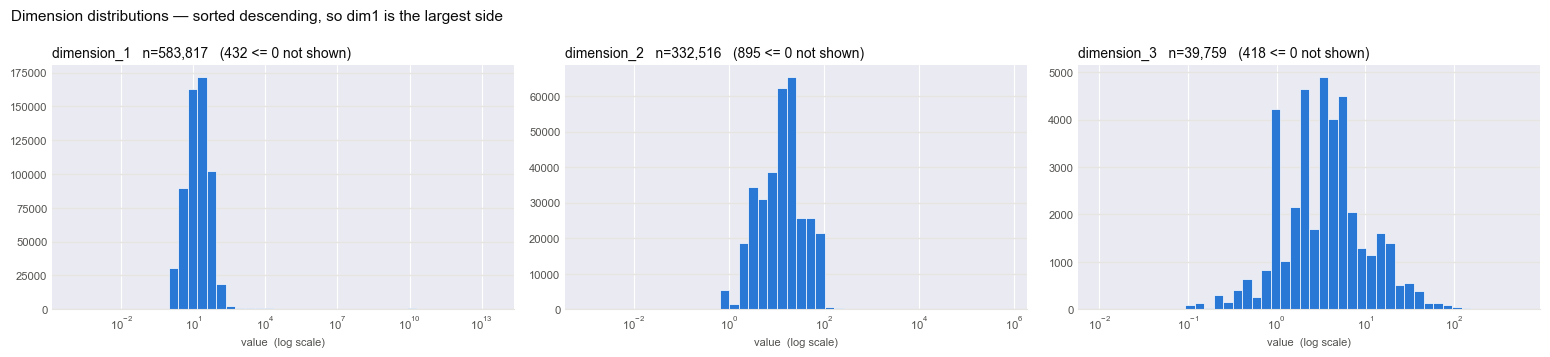

In [102]:
import matplotlib.pyplot as plt

# --- Dimension variables ---------------------------------------------------
# `Dimensions` parses into three numbers plus one shared unit column. The three
# are sorted descending (dim1 >= dim2 >= dim3), so they are "largest / middle /
# smallest side", not length / width / height.

DIM_COLS = ["dimension_1", "dimension_2", "dimension_3"]
UNIT_COL = "dimension_unit"
Q = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.96, 0.97, 0.98, 0.99]

BAR, INK, INK_SOFT, GRID = "#2a78d6", "#0b0b0b", "#52514e", "#e6e5e1"


def dimension_report(cols=DIM_COLS, unit_col=UNIT_COL, top_units=25):
    cols = [c for c in cols if c in df_features.columns]

    # --- the unit column ---------------------------------------------------
    if unit_col in df_features.columns:
        u = df_features[unit_col]
        vc = u.value_counts(dropna=True)
        print(f"{unit_col}: {u.nunique():,} distinct values, "
              f"{u.notna().sum():,} non-null ({u.notna().mean():.1%} of items)")
        print(f"  top {min(top_units, len(vc))} by item count:")
        for name, n in vc.head(top_units).items():
            print(f"      {name!r:22s} {n:>9,}  ({n / vc.sum() * 100:5.1f}%)")
        if len(vc) > top_units:
            print(f"      ... and {len(vc) - top_units:,} more, "
                  f"{vc.iloc[top_units:].sum():,} items")
        print()

    # --- percentiles -------------------------------------------------------
    rows = {}
    for c in cols:
        v = df_features[c].dropna()
        rows[c] = {"n": len(v), "coverage_%": df_features[c].notna().mean() * 100,
                   "min": v.min(),
                   **{f"p{int(q * 100)}": v.quantile(q) for q in Q},
                   "max": v.max(), "<=0": int((v <= 0).sum())}
    display(pd.DataFrame(rows).T)
    print("values pool every unit in the column above — read them together\n")

    # --- histograms --------------------------------------------------------
    fig, axes = plt.subplots(1, len(cols), figsize=(5.2 * len(cols), 3.6), squeeze=False)
    fig.patch.set_facecolor("white")
    for ax, c in zip(axes.flat, cols):
        v = df_features[c].dropna()
        pos = v[v > 0]
        use_log = len(pos) and pos.max() / pos.min() > 100
        data = pos if use_log else v
        nbins = int(np.clip(np.sqrt(max(len(data), 1)), 10, 45))
        edges = (np.logspace(np.log10(data.min()), np.log10(data.max()), nbins)
                 if use_log and data.max() > data.min()
                 else np.linspace(data.min(), data.max(), nbins))
        ax.hist(data, bins=edges, color=BAR, edgecolor="white", linewidth=0.5)
        if use_log:
            ax.set_xscale("log")
        drop = int((v <= 0).sum())
        ax.set_title(f"{c}   n={len(v):,}" + (f"   ({drop} <= 0 not shown)" if drop and use_log else ""),
                     fontsize=10, color=INK, loc="left")
        ax.set_xlabel("value" + ("  (log scale)" if use_log else ""), fontsize=8, color=INK_SOFT)
        ax.grid(axis="y", color=GRID, linewidth=1)
        ax.set_axisbelow(True)
        for side in ("top", "right", "left"):
            ax.spines[side].set_visible(False)
        ax.spines["bottom"].set_color(GRID)
        ax.tick_params(colors=INK_SOFT, labelsize=8, length=0)
    fig.suptitle("Dimension distributions — sorted descending, so dim1 is the largest side",
                 fontsize=11, color=INK, x=0.01, ha="left")
    fig.tight_layout()
    plt.show()


dimension_report()

In [105]:
df_features[df_features['dimension_unit'] == 'w'][['dimension_unit', 'dimension_1', 'dimension_2', 'dimension_3']].head()

,dimension_unit,dimension_1,dimension_2,dimension_3
4299,w,24.00,18.00,NaN
5480,w,18.00,14.00,NaN
8275,w,40.00,16.00,NaN
8276,w,20.00,15.00,NaN
8326,w,19.00,17.00,NaN


### 3.6 Feature coverage by `cat_2`

How much of each `cat_2` each feature actually covers — "what share of Furniture
items carry a `Color`" — split into categorical and numeric, using the
range-cleaned column wherever one exists.

**Read the `—` cells carefully.** A field only exists where its `cat_3` schema in
`master_metadata.json` declares it: `Filter_Rating` is declared in 1 of 69
schemas, `Scent` in 2, `Capacity_Volume` in 16, while `Color` / `Material` /
`Product_Type` / `Brand` / `Features` are in all 69. So a blank cell means *the
field was never asked for under that `cat_2`* — structurally absent, not a
failure of the extractor. A literal `0.0%` means the opposite: it was asked for
and never matched.

That distinction is the point of the **`in-scope_%`** column, which is the number
to judge a feature on. `all_%` divides by the whole 1.13M-item catalog and so
punishes every narrow field equally; `in-scope_%` divides only by the items whose
own schema declares the field. A feature at 0.4% of the catalog but 60%
in-scope is *narrow but healthy* — keep it, restricted to its categories. A
feature that is low on **both** is genuinely dead weight.

For the numeric table, two extra columns separate "rarely extracted" from
"extracted then thrown away": `raw_%` is coverage before range cleaning, and
`survived_%` is the share of extracted values the range filter kept. A low
`survived_%` says the regex is mostly capturing the wrong number — a parsing
problem, not a sparsity problem, and one worth fixing before dropping the
column.

In [49]:
import json
from collections import defaultdict

# --- Coverage of every extracted feature, per cat_2 ------------------------
# Denominator is *all items in that cat_2* (so "% of Furniture items with a
# Color") — but a field only exists where its cat_3 schema declares it, so a
# cell shows "—" when no cat_3 under that cat_2 defines the field at all.
# That keeps a real 0.0% (declared, never matched -> dead) distinguishable
# from a structural blank (never asked for -> not the feature's fault).

with open(DATA_DIR / "master_metadata.json") as f:
    master_metadata = json.load(f)

# feature column -> the master_metadata field it comes from (None = not extracted)
CATEGORICAL_FEATURES = {
    "brand":         None,             # Amazon metadata column, not from a schema
    "cat_4_clean":   None,             # 'Missing' / '*_Other' count as NOT covered
    "Brand":         "Brand",
    "Color":         "Color",
    "Features":      "Features",
    "Filter_Rating": "Filter_Rating",
    "Material":      "Material",
    "Part_Number":   "Part_Number",
    "Product_Type":  "Product_Type",
    "Scent":         "Scent",
    "Shape":         "Shape",
    "Shape_Style":   "Shape_Style",
    "Size":          "Size",
    "Sub_Type":      "Sub_Type",
    "Theme":         "Theme",
}

# The range-cleaned variant wherever one exists, raw otherwise.
NUMERIC_FEATURES = {
    "bar_pressure_numeric_cleaned":  "Bar_Pressure",
    "capacity_cups_numeric_cleaned": "Capacity_Cups",
    "density_weight_lb_cleaned":     "Density_Weight",
    "pocket_depth_in_cleaned":       "Pocket_Depth",
    "power_rating_w_cleaned":        "Power_Rating",
    "stage_count_numeric_cleaned":   "Stage_Count",
    "voltage_numeric_cleaned":       "Voltage",
    "thread_count_numeric_cleaned":  "Thread_Count",
    "weight_numeric_cleaned":        "Weight",
    "capacity_volume_numeric":       "Capacity_Volume",   # no _cleaned variant:
    "piece_count_numeric":           "Piece_Count",       # these carry a *_unit
                                                          # column and mix units
    "dimension_1":                   "Dimensions",
    "dimension_2":                   "Dimensions",
    "dimension_3":                   "Dimensions",
}

# --- which cat_3 / cat_2 actually declare each field -----------------------
cat3_by_field = defaultdict(set)
for _c3, _schema in master_metadata.items():
    for _field in _schema:
        cat3_by_field[_field].add(_c3)

cat2_of_cat3 = df_features.drop_duplicates("cat_3").set_index("cat_3")["cat_2"]
CAT2 = sorted(df_features["cat_2"].dropna().unique())
cat2_series = df_features["cat_2"]


def _is_present(col):
    """True where the feature actually carries a usable value."""
    s = df_features[col]
    if col == "cat_4_clean":                       # bucket values aren't coverage
        return s.notna() & s.ne("Missing") & ~s.astype(str).str.endswith("_Other")
    if s.dtype.kind in "fiu":
        return s.notna()
    return s.notna() & s.astype(str).str.strip().ne("")


def _coverage(features, with_range_cols=False):
    recs = []
    for col, field in features.items():
        present = _is_present(col)
        pct = present.groupby(cat2_series).mean().mul(100)

        # cat_2 values where at least one cat_3 declares this field
        declared = (
            {cat2_of_cat3.get(c3) for c3 in cat3_by_field[field]} if field else set(CAT2)
        )
        in_scope = (
            df_features["cat_3"].isin(cat3_by_field[field])
            if field else pd.Series(True, index=df_features.index)
        )

        row = {"feature": col, "field": field or "—"}
        for c2 in CAT2:
            row[c2] = pct.get(c2, np.nan) if c2 in declared else np.nan
        row["all_%"] = present.mean() * 100
        row["in-scope_%"] = present[in_scope].mean() * 100 if in_scope.any() else np.nan
        row["n_items"] = int(present.sum())

        if with_range_cols:
            raw_col = col[: -len("_cleaned")] if col.endswith("_cleaned") else col
            raw = df_features[raw_col].notna()
            row["raw_%"] = raw.mean() * 100
            row["survived_%"] = present.sum() / raw.sum() * 100 if raw.sum() else np.nan

        recs.append(row)

    return (pd.DataFrame(recs)
              .set_index(["feature", "field"])
              .sort_values("in-scope_%", ascending=False))


def _fmt(tab):
    out = tab.copy()
    for c in out.columns:
        if c == "n_items":
            out[c] = out[c].map("{:,}".format)
        else:
            out[c] = out[c].map(lambda v: "—" if pd.isna(v) else f"{v:.1f}%")
    return out


print("items per cat_2")
print(df_features["cat_2"].value_counts().to_string(), "\n")

cat_tab = _coverage(CATEGORICAL_FEATURES)
num_tab = _coverage(NUMERIC_FEATURES, with_range_cols=True)

print("=" * 100)
print("CATEGORICAL — % of items in each cat_2 carrying the feature")
print("  in-scope_% = coverage among items whose cat_3 declares the field (the honest number)")
print("=" * 100)
display(_fmt(cat_tab))

print("=" * 100)
print("NUMERIC (range-cleaned where a _cleaned column exists)")
print("  raw_%      = coverage before range cleaning")
print("  survived_% = share of extracted values the range filter kept — low means the")
print("               extraction is mostly capturing the wrong number")
print("=" * 100)
display(_fmt(num_tab))

items per cat_2
cat_2
Kitchen & Dining    429949
Home Dcor           343481
Bedding             130115
Wall Art            108969
Furniture            69232
Bath                 51945
Kids' Home Store       875 

CATEGORICAL — % of items in each cat_2 carrying the feature
  in-scope_% = coverage among items whose cat_3 declares the field (the honest number)


,,Bath,Bedding,Furniture,Home Dcor,Kids' Home Store,Kitchen & Dining,Wall Art,all_%,in-scope_%,n_items
feature,field,,,,,,,,,,
brand,—,92.9%,91.0%,96.4%,95.4%,90.5%,95.4%,90.1%,94.3%,94.3%,"1,070,090"
cat_4_clean,—,88.2%,92.2%,93.7%,91.8%,97.3%,94.7%,0.0%,84.1%,84.1%,"954,174"
Size,Size,—,55.1%,13.4%,0.3%,—,—,—,7.2%,74.7%,"81,941"
Product_Type,Product_Type,85.7%,88.8%,77.1%,71.0%,66.9%,71.3%,67.7%,73.9%,73.9%,"838,262"
Material,Material,78.6%,75.8%,78.3%,63.1%,52.3%,65.4%,63.7%,67.1%,67.1%,"761,739"
Features,Features,60.1%,78.1%,71.2%,52.6%,52.9%,45.9%,71.4%,56.3%,56.3%,"638,614"
Filter_Rating,Filter_Rating,—,—,—,—,—,0.5%,—,0.2%,53.9%,"2,136"
Shape_Style,Shape_Style,—,13.2%,—,5.0%,—,—,—,3.0%,53.4%,"34,514"
Color,Color,46.6%,51.9%,70.3%,47.9%,32.3%,46.7%,22.3%,46.7%,46.7%,"530,245"


NUMERIC (range-cleaned where a _cleaned column exists)
  raw_%      = coverage before range cleaning
  survived_% = share of extracted values the range filter kept — low means the
               extraction is mostly capturing the wrong number


,,Bath,Bedding,Furniture,Home Dcor,Kids' Home Store,Kitchen & Dining,Wall Art,all_%,in-scope_%,n_items,raw_%,survived_%
feature,field,,,,,,,,,,,,
dimension_1,Dimensions,62.7%,51.6%,46.7%,53.8%,—,39.6%,88.7%,51.5%,58.9%,"583,817",51.5%,100.0%
capacity_numeric,Capacity,—,—,—,—,—,0.9%,—,0.4%,56.9%,"4,026",0.4%,100.0%
weight_numeric_cleaned,Weight,—,—,—,0.1%,—,—,—,0.0%,49.1%,251,0.0%,99.6%
thread_count_numeric_cleaned,Thread_Count,—,14.8%,—,—,—,—,—,1.7%,44.6%,"19,264",1.7%,99.6%
capacity_volume_numeric,Capacity_Volume,14.6%,—,1.7%,4.7%,2.5%,23.2%,—,11.0%,40.0%,"124,755",11.0%,100.0%
capacity_cups_numeric_cleaned,Capacity_Cups,—,—,—,—,—,0.6%,—,0.2%,37.6%,"2,664",0.2%,98.6%
dimension_2,Dimensions,45.7%,37.8%,25.0%,26.0%,—,16.2%,76.5%,29.3%,33.5%,"332,516",29.3%,100.0%
power_rating_w_cleaned,Power_Rating,—,—,—,—,—,1.4%,—,0.5%,32.3%,"5,961",0.5%,98.2%
density_weight_lb_cleaned,Density_Weight,—,0.3%,—,—,—,—,—,0.0%,28.7%,328,0.0%,96.2%


### 3.7 Redundancy between features — am I extracting the same thing twice?

`Capacity` was a duplicate of `Capacity_Cups` + `Capacity_Volume` — all three
were declared in the same `Coffee, Tea & Espresso` schema with overlapping
patterns, so one match filled two columns. **It was not the only pair like
that.** Linting all 69 schemas for fields that claim the same unit literal finds
four:

| cat_3 | Fields | Shared claim | Status |
| --- | --- | --- | --- |
| Coffee, Tea & Espresso | `Capacity` ↔ `Capacity_Cups` | `cup` | **fixed** — `Capacity` deleted |
| Coffee, Tea & Espresso | `Capacity` ↔ `Capacity_Volume` | `oz` | **fixed** — `Capacity` deleted |
| Bakeware | `Dimensions` ↔ `Piece_Count` | `count` | open |
| Bedding Accessories | `Dimensions` ↔ `Piece_Count` | `x` | open |

The last two are worse than duplication — they're **cross-contamination**.
Bakeware's `Dimensions` claims `count`, `qt`, `quart` and `oz`, so `dimension_1`
there holds quantities and volumes mixed in with inches. Bedding Accessories'
`Piece_Count` claims `x(\d+)`, so the `24x36` in every bedding size parses as a
piece count of 36. Only `Capacity` is a clean delete; those two need their
patterns fixed instead.

Dictionary fields overlap too, on **values** rather than patterns: `Color` and
`Material` share `mahogany`, `pine`, `oak`, `walnut` in ~50 schemas — words that
are legitimately both a colour and a wood — so one mention fills both fields.
Same shape in `Features` ↔ `Shape` (`oval`, `round`, `square`),
`Features` ↔ `Sub_Type`, `Shape` ↔ `Shape_Style` (`square`, `rectangle`), and
`Brand` ↔ `Theme` (`disney`).

The cell below measures all of that **in the data** rather than in the schema:

- **A. Co-presence** — do two features fire on the same items? `containment ≈ 1.0`
  means the smaller feature is entirely inside the larger and adds no new items.
  This is the check that would have caught `Capacity` immediately.
- **B. Numeric pairs** — same number where both fire. `identical_% ≈ 100` is a
  literal duplicate; high `spearman` with low `identical_%` is a deterministic
  relationship — a unit conversion or a truncated decimal — which is still
  redundant, just not obviously so.
- **C. Categorical pairs** — same string where both fire, plus the size of the
  shared vocabulary and Cramér's V.
- **D. Same field, different text source** — `title` vs `description` vs
  `feature`. This is `merge_extracted`'s `priority` seen from the other side:
  where the sources agree, the extra source is redundant and the priority order
  is irrelevant; where they disagree, priority is silently picking a winner.

`Capacity` has been removed from `master_metadata.json` and from
`NUMERIC_UNIT_FIELDS`, so `capacity_numeric` / `capacity_unit` disappear on the
next extraction and are no longer measured here. The pairs still worth watching
are the two `Dimensions` ↔ `Piece_Count` ones above — anything landing near the
top of A or B deserves the same scrutiny `Capacity` got.

In [ ]:
from itertools import combinations

# --- Redundancy between extracted features --------------------------------
# Reuses CATEGORICAL_FEATURES / NUMERIC_FEATURES / _is_present from 3.6.
# Three questions, three blocks:
#   A. do two features fire on the SAME ITEMS?      (co-presence)
#   B. do two numeric features carry the SAME NUMBER?
#   C. do two categorical features carry the SAME STRING?
# Capacity was the find that motivated this; it is now deleted from the schema, so the
# pairs left to watch are Dimensions vs Piece_Count in Bakeware / Bedding Accessories.

MIN_N = 30        # ignore pairs with fewer co-occurrences than this
MAX_LEVELS = 150  # skip Cramer's V above this cardinality (crosstab blows up)

CAT_COLS = [c for c in CATEGORICAL_FEATURES if c in df_features.columns]
NUM_COLS = [c for c in NUMERIC_FEATURES if c in df_features.columns]
ALL_COLS = CAT_COLS + NUM_COLS

presence = pd.DataFrame({c: _is_present(c) for c in ALL_COLS})

# --- A. co-presence -------------------------------------------------------
M = presence.to_numpy(dtype=np.float32)
inter = M.T @ M
n_each = M.sum(0)
union = n_each[:, None] + n_each[None, :] - inter
jaccard = np.divide(inter, np.maximum(union, 1))
contain = np.divide(inter, np.maximum(np.minimum(n_each[:, None], n_each[None, :]), 1))

rows = []
for i, j in combinations(range(len(ALL_COLS)), 2):
    if inter[i, j] < MIN_N:
        continue
    rows.append({
        "feature_a": ALL_COLS[i], "feature_b": ALL_COLS[j],
        "n_a": int(n_each[i]), "n_b": int(n_each[j]), "n_both": int(inter[i, j]),
        "jaccard": jaccard[i, j],          # symmetric overlap
        "containment": contain[i, j],      # share of the SMALLER one inside the larger
    })
co_presence = (pd.DataFrame(rows)
                 .sort_values("containment", ascending=False)
                 .reset_index(drop=True))

print("=" * 100)
print("A. CO-PRESENCE — which features fire on the same items")
print("   containment = n_both / min(n_a, n_b); ~1.0 means the smaller feature is fully")
print("   contained in the larger one, i.e. it adds no new items")
print("=" * 100)
display(co_presence.head(25).round({"jaccard": 3, "containment": 3}))

# --- B. numeric agreement -------------------------------------------------
rows = []
for a, b in combinations(NUM_COLS, 2):
    m = presence[a] & presence[b]
    n = int(m.sum())
    if n < MIN_N:
        continue
    x, y = df_features.loc[m, a], df_features.loc[m, b]
    rows.append({
        "feature_a": a, "feature_b": b, "n_both": n,
        "pearson": x.corr(y),
        "spearman": x.corr(y, method="spearman"),
        "identical_%": (x == y).mean() * 100,
    })
numeric_pairs = (pd.DataFrame(rows)
                   .sort_values("identical_%", ascending=False)
                   .reset_index(drop=True))

print("\n" + "=" * 100)
print("B. NUMERIC PAIRS — same number on the rows where both fire")
print("   identical_% near 100 = literal duplicate. High spearman with low identical_% =")
print("   a deterministic relationship (unit conversion, truncated decimals), still redundant.")
print("=" * 100)
display(numeric_pairs)

# --- C. categorical agreement --------------------------------------------
def cramers_v(x, y):
    ct = pd.crosstab(x, y).to_numpy(dtype=float)
    n = ct.sum()
    if n == 0 or min(ct.shape) < 2:
        return np.nan
    exp = np.outer(ct.sum(1), ct.sum(0)) / n
    chi2 = ((ct - exp) ** 2 / np.where(exp == 0, 1, exp)).sum()
    return np.sqrt((chi2 / n) / (min(ct.shape) - 1))

rows = []
for a, b in combinations(CAT_COLS, 2):
    m = presence[a] & presence[b]
    n = int(m.sum())
    if n < MIN_N:
        continue
    x = df_features.loc[m, a].astype(str).str.strip().str.lower()
    y = df_features.loc[m, b].astype(str).str.strip().str.lower()
    small = x.nunique() <= MAX_LEVELS and y.nunique() <= MAX_LEVELS
    rows.append({
        "feature_a": a, "feature_b": b, "n_both": n,
        "levels_a": x.nunique(), "levels_b": y.nunique(),
        "identical_%": (x == y).mean() * 100,
        "shared_values": len(set(x.unique()) & set(y.unique())),
        "cramers_v": cramers_v(x, y) if small else np.nan,
    })
categorical_pairs = (pd.DataFrame(rows)
                       .sort_values(["identical_%", "shared_values"], ascending=False)
                       .reset_index(drop=True))

print("\n" + "=" * 100)
print("C. CATEGORICAL PAIRS — same string on the rows where both fire")
print("   shared_values = vocabulary the two fields have in common (Color/Material share")
print("   'mahogany', 'pine', 'oak' in ~50 schemas — a word that is both a colour and a wood)")
print("   cramers_v = association strength, blank where cardinality is too high to crosstab")
print("=" * 100)
display(categorical_pairs.head(30))

# --- D. same field, different text source ---------------------------------
# Does title / description / feature extract the SAME value for the same field?
# This is the merge in `merge_extracted` seen from the other side: priority only
# matters where the sources disagree.
RUN_SOURCE_AGREEMENT = True   # ~1 min over 1.13M rows; set False to skip

if RUN_SOURCE_AGREEMENT:
    SOURCES = ["title", "description", "feature"]
    src = {s: df_features[f"extracted_features_{s}"].to_numpy() for s in SOURCES}

    rows = []
    for a, b in combinations(SOURCES, 2):
        both_n, agree_n = {}, {}
        for da, db in zip(src[a], src[b]):
            if not isinstance(da, dict) or not isinstance(db, dict):
                continue
            for k in da.keys() & db.keys():
                both_n[k] = both_n.get(k, 0) + 1
                agree_n[k] = agree_n.get(k, 0) + (da[k] == db[k])
        for k, n in both_n.items():
            if n >= MIN_N:
                rows.append({"field": k, "source_a": a, "source_b": b,
                             "n_both": n, "agree_%": agree_n[k] / n * 100})

    source_agreement = (pd.DataFrame(rows)
                          .sort_values(["field", "n_both"], ascending=[True, False])
                          .reset_index(drop=True))

    print("\n" + "=" * 100)
    print("D. SAME FIELD, DIFFERENT TEXT SOURCE — title vs description vs feature")
    print("   agree_% high  -> the extra source is redundant, priority order is irrelevant")
    print("   agree_% low   -> the sources genuinely disagree and `priority` decides the")
    print("                    value silently; worth knowing which one you are trusting")
    print("=" * 100)
    display(source_agreement)

## 4. Join the item features onto the interactions

With the examination above settled, attach the item columns to the interaction
table on `asin`. Left join, so no interaction is dropped: items with no
extracted features keep their row with NaN item columns (~16% of rows —
those asins either aren't in the item metadata, or were dropped during
extraction because their `cat_3` has no schema).

The cell below currently attaches **every** field and measure column. Once §3
has produced a keep-list, narrow `keep_cols` to it — that is the one place the
exclusion decision needs to be applied.

In [ ]:
# --- Connect the two on `asin` ---
# Attach ALL extracted feature variables plus their parsed measures.

# 1. Every extracted feature field column (the keys present in the dicts):
#    Product_Type, Material, Color, Weight, Dimensions, Brand, Theme, ...
field_cols = sorted({
    k for d in df_features["extracted_features"]
    if isinstance(d, dict) for k in d
})

# 2. Their parsed measures: numeric value + unit (+ dimension_1/2/3).
#    Use the range-cleaned numeric variant wherever one exists.
measure_cols = [
    c for c in df_features.columns
    if c.endswith("_numeric") or c.endswith("_unit")
    or c.startswith("dimension_")
    or c in ("density_weight_lb", "pocket_depth_in", "power_rating_w")
]
measure_cols = sorted({
    f"{c}_cleaned" if f"{c}_cleaned" in df_features.columns else c
    for c in measure_cols
})

# 3. Context columns to carry along (asin is the join key).
# cat_4_clean (from category_taxonomy.json) replaces the raw cat_4 here —
# the ~920 raw values are mostly bullet text, see section 3.
context_cols = ["asin", "cat_2", "cat_3", "cat_4_clean", "brand", "extracted_features"]

keep_cols = list(dict.fromkeys(context_cols + field_cols + measure_cols))
keep_cols = [c for c in keep_cols if c in df_features.columns]

df = df_reviews.merge(
    df_features[keep_cols],
    on="asin",
    how="left",
    validate="many_to_one",   # many reviews -> one item row
    indicator=True,
)
n_unmatched = (df["_merge"] == "left_only").sum()
df = df.drop(columns="_merge")

print(f"merged: {df.shape}  ({len(keep_cols)} item cols attached)")
print(f"  feature fields : {len(field_cols)}")
print(f"  measure cols   : {len(measure_cols)}")
print(f"unique users: {df['reviewerID'].nunique():,} | "
      f"unique items: {df['asin'].nunique():,}")
print(f"reviews with no matching item features: {n_unmatched:,}")
df.head(5)

## 5. User features

`data/df_user_features.pkl` — built by
`feature_extraction_workflow/extract_features_user.py`. **One row per purchase
event** with 22 features, each computed only from that user's purchases on
**strictly earlier days**, so no row can see its own or any later interaction.
See that module's section in `feature_extraction_workflow/README.md`.

### Why this is a positional concat, not a merge

The natural key is (user, item, date) — joining on `reviewerID` alone would be a
real leak, attaching every event's feature vector, including future ones, to
every row of that user.

But that triple **isn't unique in this log**: 501,704 rows share a
`(reviewerID, asin, unixReviewTime)` triple with at least one other row, so a
key merge is many-to-many and square-joins those groups into **+572,198 phantom
rows (+8.3%)**.

The pickle was generated from this exact CSV, in file order, dropping nothing —
so row *i* of the pickle already is row *i* of the log. Aligning by position
gives identical semantics with zero fanout.

The asserts below **verify** that alignment element-wise instead of assuming it.
They also confirm the row order survived the item join in §4. If the pickle is
ever regenerated from a different or reordered log, this fails loudly rather
than silently pairing the wrong user's history to a row.

**Expect ~23.5% of rows to have all-NaN user features.** That's a user's first
purchase (and anything on that same first day) — there is no prior history to
summarize. Intended, not a defect.

In [ ]:
df_user_features = pd.read_pickle(DATA_DIR / "df_user_features.pkl")
print("df_user_features:", df_user_features.shape)
display(df_user_features.head(3))

# --- Verify positional alignment before relying on it ---
assert len(df_user_features) == len(df), (
    f"row count mismatch: user features {len(df_user_features):,} vs "
    f"interactions {len(df):,}"
)
for key in ("reviewerID", "asin", "unixReviewTime"):
    n_bad = int((df_user_features[key].to_numpy() != df[key].to_numpy()).sum())
    assert n_bad == 0, f"row order mismatch on {key}: {n_bad:,} rows differ"
print("alignment verified: reviewerID / asin / unixReviewTime match row-for-row\n")

# Attach the 22 feature columns (the key columns are already in df)
USER_FEATURE_COLS = [
    c for c in df_user_features.columns
    if c not in ("reviewerID", "asin", "reviewTime", "unixReviewTime")
]
df = pd.concat(
    [df.reset_index(drop=True),
     df_user_features[USER_FEATURE_COLS].reset_index(drop=True)],
    axis=1,
)

n_cold = int(df["prior_purchase_count"].isna().sum())
print(f"attached {len(USER_FEATURE_COLS)} user feature columns -> df {df.shape}")
print(f"cold-start rows (empty history, all user features NaN): "
      f"{n_cold:,} ({n_cold / len(df) * 100:.1f}%)")
df.head(5)